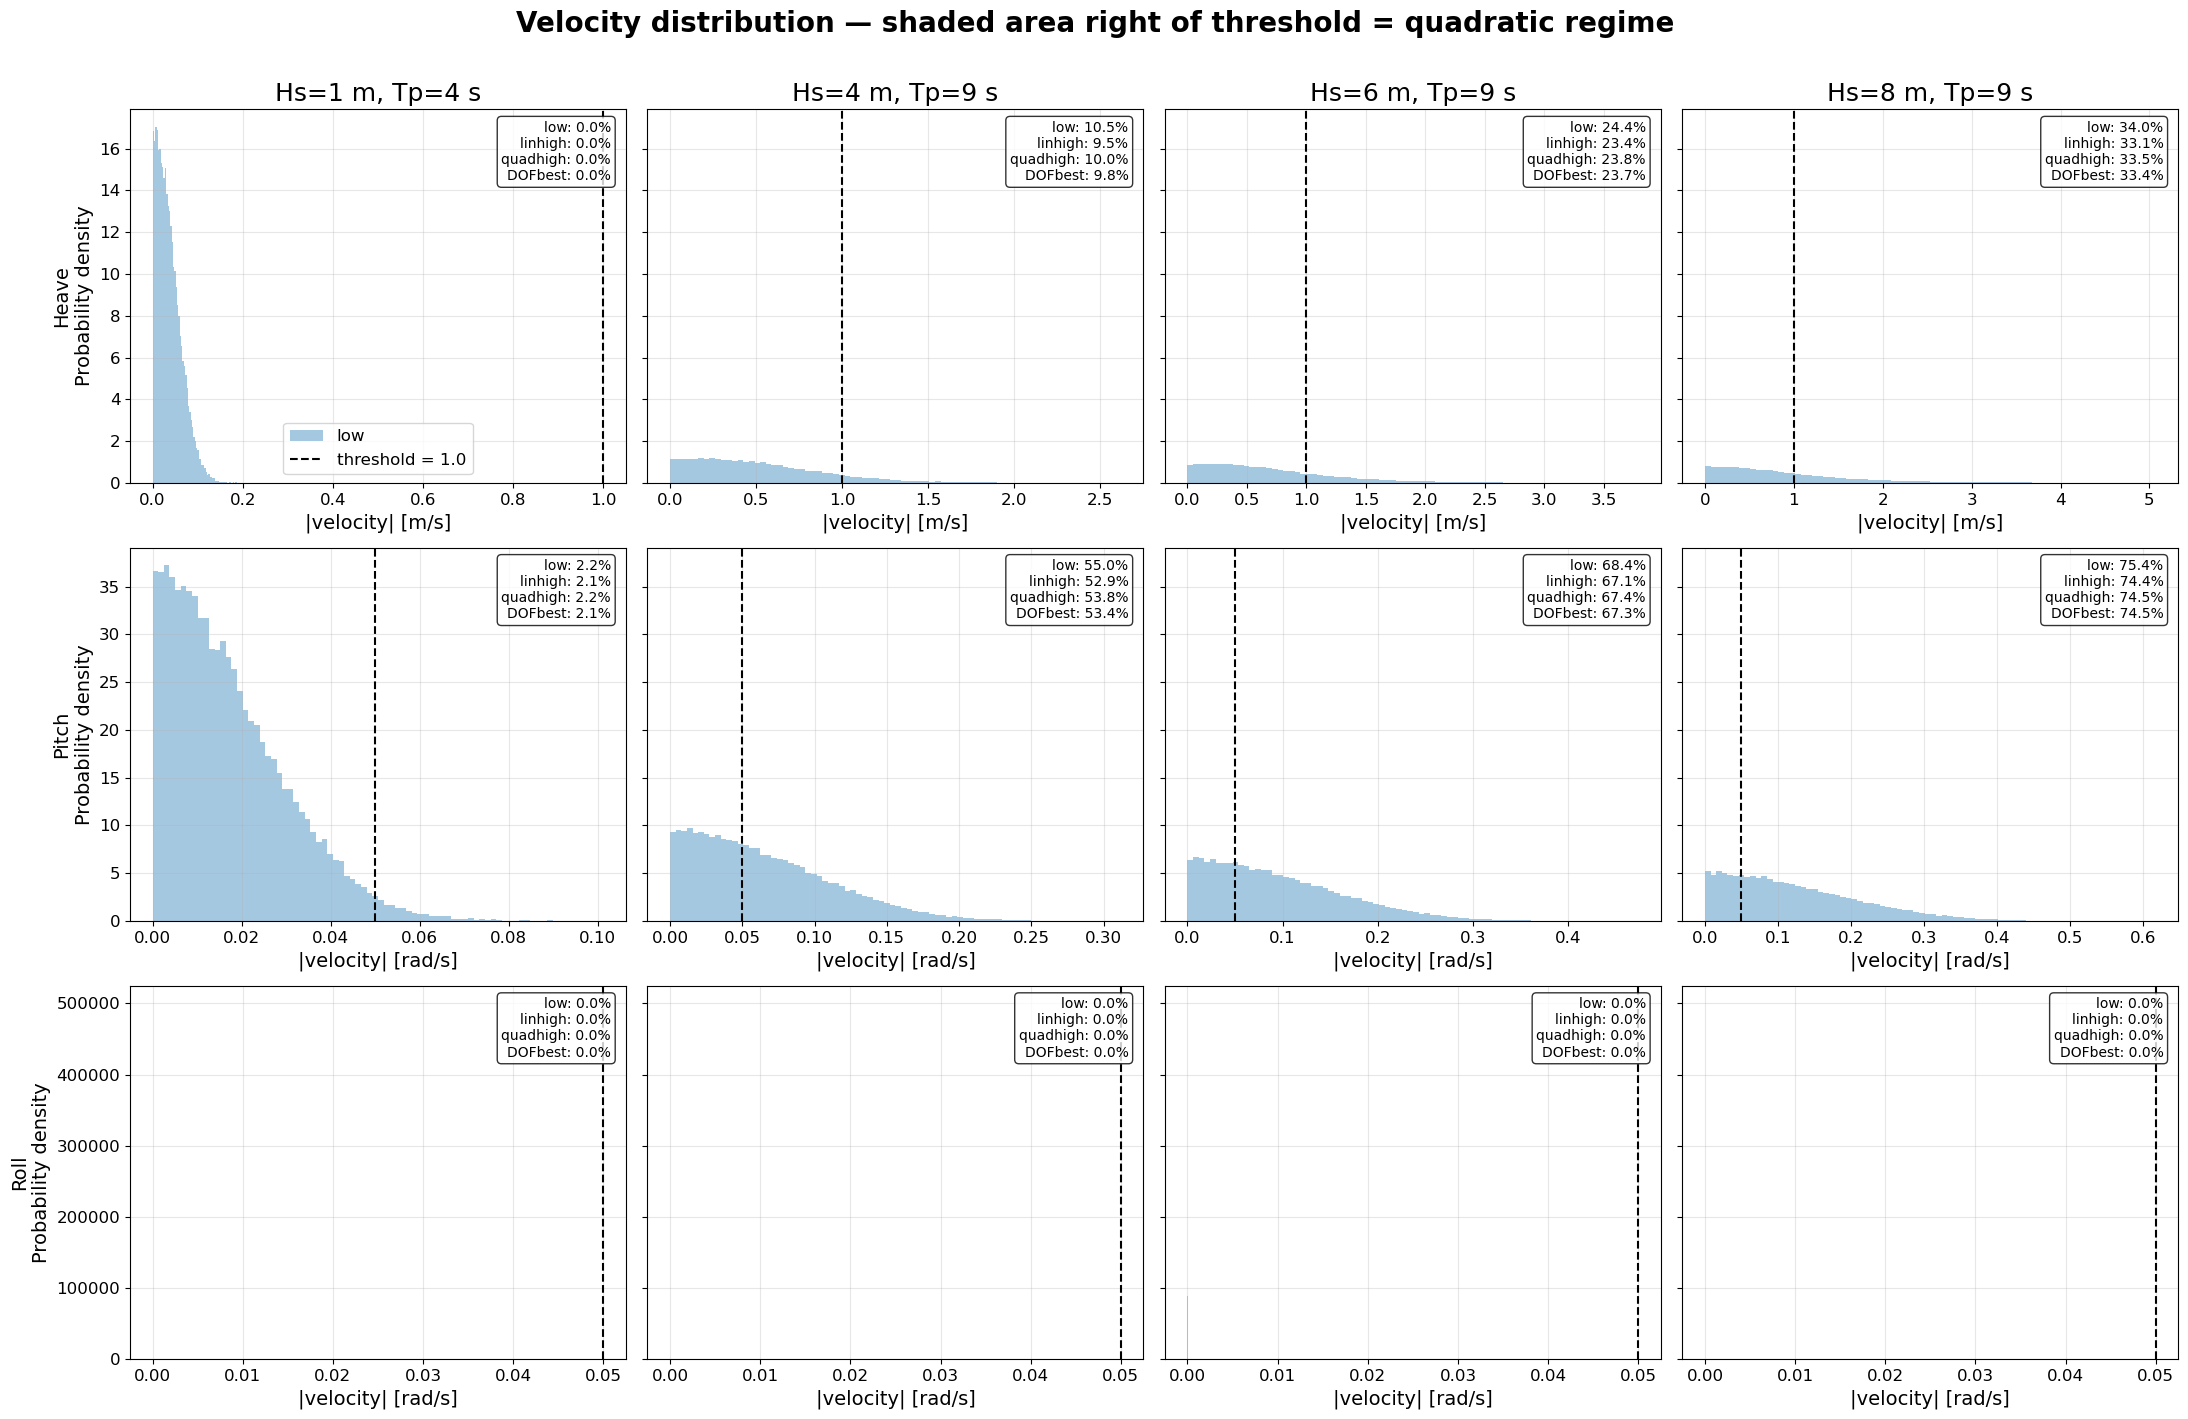

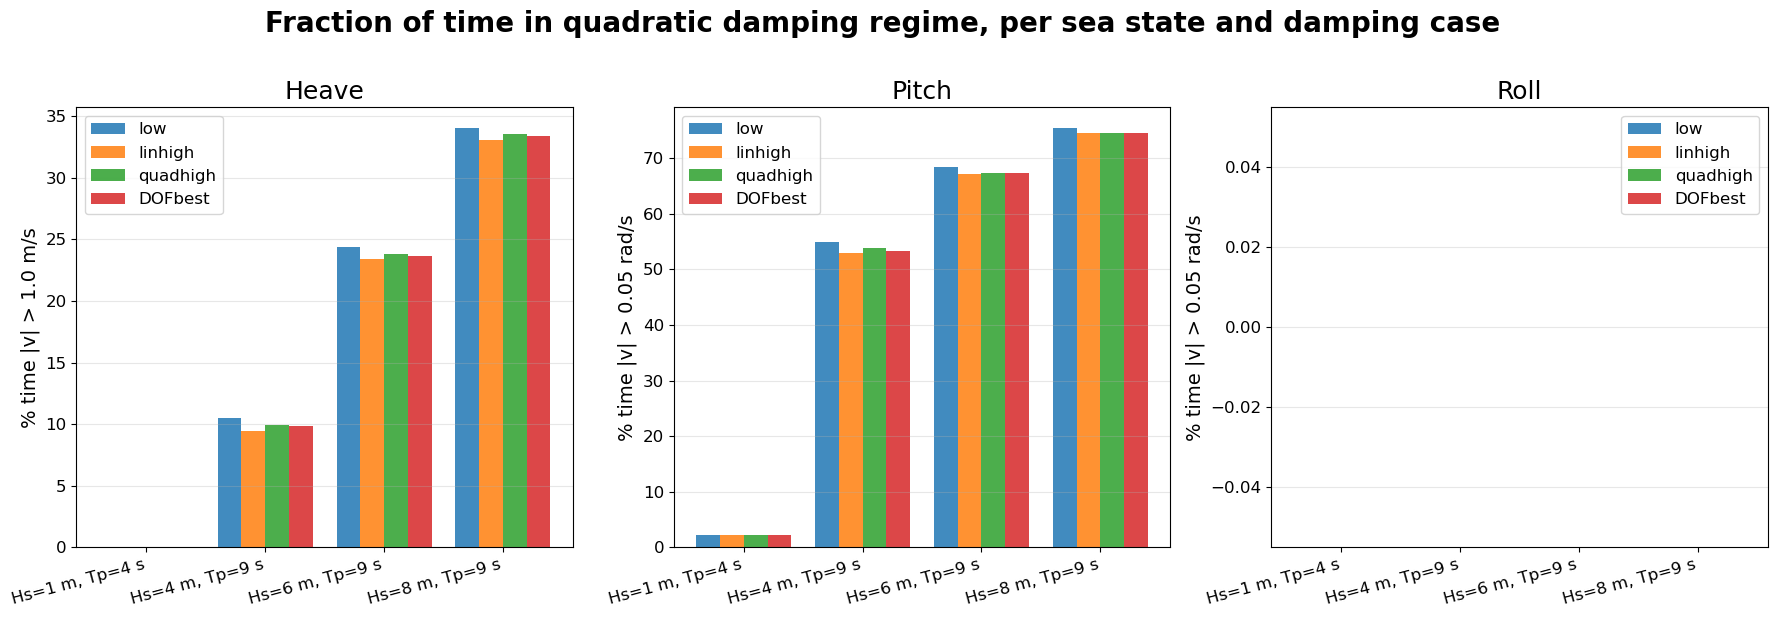

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('velocity_timehistory.csv')

TITLE_SIZE = 18
LABEL_SIZE = 14
TICK_SIZE = 12

SEASTATES = [
    {'label': 'Hs1_Tp4', 'title': 'Hs=1 m, Tp=4 s'},
    {'label': 'Hs4_Tp9', 'title': 'Hs=4 m, Tp=9 s'},
    {'label': 'Hs6_Tp9', 'title': 'Hs=6 m, Tp=9 s'},
    {'label': 'Hs8_Tp9', 'title': 'Hs=8 m, Tp=9 s'},
]
DOFS = [
    {'key': 'v_Z',     'name': 'Heave', 'unit': 'm/s',   'threshold': 1.0},
    {'key': 'v_pitch', 'name': 'Pitch', 'unit': 'rad/s', 'threshold': 0.05},
    {'key': 'v_roll',  'name': 'Roll',  'unit': 'rad/s', 'threshold': 0.05},
]
DAMP_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'DOFbest':  '#d62728',
}
N_T = len(df)

fig, axes = plt.subplots(3, 4, figsize=(22, 14), sharey='row')

for r, dof in enumerate(DOFS):
    thresh = dof['threshold']
    for c, ss in enumerate(SEASTATES):
        ax = axes[r, c]
        col_low = f'{ss["label"]}_low_{dof["key"]}'
        v_low = df[col_low].values

        # --- Histogram van |v| voor low-damping ---
        ax.hist(np.abs(v_low), bins=80, density=True,
                color=DAMP_COLORS['low'], alpha=0.4, label='low')

        # --- Drempel lijn ---
        ax.axvline(thresh, color='black', lw=1.5, ls='--',
                   label=f'threshold = {thresh}')

        # --- % tijd boven drempel per damping case ---
        pct_text = []
        for damp in ['low', 'linhigh', 'quadhigh', 'DOFbest']:
            col = f'{ss["label"]}_{damp}_{dof["key"]}'
            if col not in df.columns:
                continue
            v = df[col].values
            pct = (np.abs(v) > thresh).mean() * 100
            pct_text.append(f'{damp}: {pct:.1f}%')

        ax.text(0.97, 0.97, '\n'.join(pct_text),
                transform=ax.transAxes, va='top', ha='right',
                fontsize=TICK_SIZE - 2,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        ax.set_xlabel(f'|velocity| [{dof["unit"]}]', fontsize=LABEL_SIZE)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=TICK_SIZE)

        if r == 0:
            ax.set_title(ss['title'], fontsize=TITLE_SIZE)
        if c == 0:
            ax.set_ylabel(f'{dof["name"]}\nProbability density', fontsize=LABEL_SIZE)
        if r == 0 and c == 0:
            ax.legend(fontsize=TICK_SIZE)

fig.suptitle(f'Velocity distribution — shaded area right of threshold = quadratic regime',
             y=1.01, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

# --- Samenvattende staafdiagram: % tijd boven drempel ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(SEASTATES))
width = 0.2
damp_list = ['low', 'linhigh', 'quadhigh', 'DOFbest']

for ax, dof in zip(axes2, DOFS):
    thresh = dof['threshold']
    for di, damp in enumerate(damp_list):
        pcts = []
        for ss in SEASTATES:
            col = f'{ss["label"]}_{damp}_{dof["key"]}'
            if col in df.columns:
                pcts.append((np.abs(df[col].values) > thresh).mean() * 100)
            else:
                pcts.append(0)
        ax.bar(x + di * width, pcts, width,
               label=damp, color=DAMP_COLORS[damp], alpha=0.85)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels([ss['title'] for ss in SEASTATES],
                       rotation=15, ha='right', fontsize=TICK_SIZE)
    ax.set_ylabel(f'% time |v| > {dof["threshold"]} {dof["unit"]}', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=TICK_SIZE)

fig2.suptitle('Fraction of time in quadratic damping regime, per sea state and damping case',
              y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig2.tight_layout()
plt.show()